# Mini-Challenge 2: Sentiment Analysis

This notebook consolidates the entire project, keeping helper files inline except `models.py` which is needed externally for Apple Silicon performance optimization.

In [ ]:
import inspect
import os
from pathlib import Path
from typing import Dict, List

import torch

os.environ["TOKENIZERS_PARALLELISM"] = "false"
os.environ["MPLCONFIGDIR"] = os.path.abspath(".matplotlib")
os.environ["NUMBA_CACHE_DIR"] = os.path.abspath(".numba_cache")
os.makedirs(os.environ["MPLCONFIGDIR"], exist_ok=True)
os.makedirs(os.environ["NUMBA_CACHE_DIR"], exist_ok=True)

from IPython.display import display

import matplotlib.pyplot as plt
import numpy as np
import openai
import pandas as pd
import seaborn as sns
import umap
from datasets import Dataset, load_dataset
from dotenv import load_dotenv
from sentence_transformers import SentenceTransformer
from sklearn.metrics import accuracy_score, f1_score
from sklearn.model_selection import train_test_split
from sklearn.neighbors import KNeighborsClassifier, NearestNeighbors
from transformers import (
    AutoModel,
    AutoTokenizer,
    DataCollatorWithPadding,
    Trainer,
    TrainingArguments,
    logging as transformers_logging,
    set_seed as hf_set_seed,
)

from models import (
    SentimentClassifier,
    compute_confusion_matrix,
    compute_metrics,
    get_device,
)

load_dotenv(dotenv_path=Path('.env'))
transformers_logging.set_verbosity_error()


In [2]:
def _find_local_phrasebank_dir() -> Path:
    """Locate a local Financial PhraseBank cache if HF loading is unavailable."""
    candidate_roots = [
        Path.cwd() / "FinancialPhraseBank-v1.0",
        Path.home() / ".cache" / "huggingface" / "datasets" / "downloads" / "extracted",
    ]

    for root in candidate_roots:
        if not root.exists():
            continue

        if (
            root.name == "FinancialPhraseBank-v1.0"
            and (root / "Sentences_AllAgree.txt").exists()
        ):
            return root

        for candidate in root.rglob("FinancialPhraseBank-v1.0"):
            if (candidate / "Sentences_AllAgree.txt").exists():
                return candidate

    raise FileNotFoundError(
        "Could not find a local FinancialPhraseBank-v1.0 directory. "
        "Download the dataset once with Hugging Face or place the raw files locally."
    )


def _load_phrasebank_subset(
    config_name: str,
    dataset_name: str = "takala/financial_phrasebank",
) -> pd.DataFrame:
    """Load one agreement subset with a local fallback."""
    label_map = {"negative": 0, "neutral": 1, "positive": 2}
    filename_map = {
        "sentences_allagree": "Sentences_AllAgree.txt",
        "sentences_75agree": "Sentences_75Agree.txt",
        "sentences_66agree": "Sentences_66Agree.txt",
        "sentences_50agree": "Sentences_50Agree.txt",
    }

    try:
        dataset = load_dataset(dataset_name, config_name, split="train")
        df = dataset.to_pandas()[["sentence", "label"]].copy()
        if df["label"].dtype == object:
            df["label"] = df["label"].map(label_map)
    except Exception as exc:
        print(f"Falling back to local raw files for {config_name}: {exc}")
        dataset_dir = _find_local_phrasebank_dir()
        rows = []
        with open(
            dataset_dir / filename_map[config_name],
            encoding="iso-8859-1",
        ) as handle:
            for line in handle:
                sentence, label = line.rsplit("@", 1)
                rows.append(
                    {
                        "sentence": sentence,
                        "label": label_map[label.strip()],
                    }
                )
        df = pd.DataFrame(rows)

    df["agreement_subset"] = config_name
    return df


def _deduplicate_sentences(df: pd.DataFrame, subset_name: str) -> pd.DataFrame:
    """Drop duplicate sentences and keep the first occurrence."""
    duplicate_rows = df[df.duplicated(subset=["sentence"], keep=False)]
    if not duplicate_rows.empty:
        conflicting_duplicates = (
            duplicate_rows.groupby("sentence")["label"].nunique().gt(1).sum()
        )
        deduped = df.drop_duplicates(subset=["sentence"], keep="first").copy()
        removed_rows = len(df) - len(deduped)
        print(
            f"{subset_name}: removed {removed_rows} duplicate rows "
            f"across {duplicate_rows['sentence'].nunique()} duplicated sentences "
            f"({conflicting_duplicates} conflicting-label cases resolved by "
            "first occurrence)."
        )
        return deduped.reset_index(drop=True)

    return df.reset_index(drop=True)


def _attach_example_ids(df: pd.DataFrame, prefix: str) -> pd.DataFrame:
    result = df.copy().reset_index(drop=True)
    result.index = [f"{prefix}_{idx:05d}" for idx in range(len(result))]
    result.index.name = "example_id"
    return result


def load_agreement_aware_splits(
    dataset_name: str = "takala/financial_phrasebank",
    seed: int = 42,
    test_size: float = 0.2,
    val_size: float = 0.1,
    train_sizes: List[int] = [100, 250, 500, 1000],
) -> Dict[str, pd.DataFrame]:
    """Create clean train/validation/test splits with agreement awareness."""
    if train_sizes != sorted(train_sizes):
        raise ValueError("train_sizes must be sorted in ascending order.")

    max_train_size = max(train_sizes)

    print("Loading Financial PhraseBank agreement subsets...")
    allagree_df = _deduplicate_sentences(
        _load_phrasebank_subset("sentences_allagree", dataset_name),
        subset_name="100% agreement subset",
    )
    allagree_df = _attach_example_ids(allagree_df, prefix="allagree")

    non100_frames = []
    for config_name in ["sentences_75agree", "sentences_66agree", "sentences_50agree"]:
        subset_df = _load_phrasebank_subset(config_name, dataset_name)
        non100_frames.append(subset_df)

    combined_non100_df = pd.concat(non100_frames, ignore_index=True)
    combined_non100_df = combined_non100_df[
        ~combined_non100_df["sentence"].isin(set(allagree_df["sentence"]))
    ].copy()
    combined_non100_df = _deduplicate_sentences(
        combined_non100_df,
        subset_name="Combined non-100% agreement pool",
    )
    combined_non100_df = _attach_example_ids(combined_non100_df, prefix="disagree")

    remaining_allagree_df, test_allagree_df = train_test_split(
        allagree_df,
        test_size=test_size,
        random_state=seed,
        stratify=allagree_df["label"],
    )
    remaining_disagree_df, test_disagree_df = train_test_split(
        combined_non100_df,
        test_size=test_size,
        random_state=seed,
        stratify=combined_non100_df["label"],
    )

    train_hidden_allagree_df, val_allagree_df = train_test_split(
        remaining_allagree_df,
        test_size=val_size,
        random_state=seed,
        stratify=remaining_allagree_df["label"],
    )

    if len(train_hidden_allagree_df) <= max_train_size:
        raise ValueError(
            "Not enough 100%-agreement data left after test/val splits to support "
            f"max training size {max_train_size}."
        )

    shuffled_clean_pool = train_hidden_allagree_df.sample(frac=1, random_state=seed)
    hard_label_train_pool = shuffled_clean_pool.iloc[:max_train_size].copy()
    hidden_allagree_pool = shuffled_clean_pool.iloc[max_train_size:].copy()

    if hidden_allagree_pool.empty:
        raise ValueError(
            "hidden_allagree_pool is empty; adjust split sizes or train_sizes."
        )

    splits = {
        "allagree_full": allagree_df,
        "combined_non100_pool": combined_non100_df,
        "remaining_disagree_pool": remaining_disagree_df.copy(),
        "test_allagree": test_allagree_df.copy(),
        "test_disagree": test_disagree_df.copy(),
        "val_allagree": val_allagree_df.copy(),
        "hard_label_train_pool": hard_label_train_pool.copy(),
        "hidden_allagree_pool": hidden_allagree_pool.copy(),
    }

    for size in train_sizes:
        if size > len(hard_label_train_pool):
            raise ValueError(
                "Requested train size "
                f"{size} exceeds available hard-label pool "
                f"{len(hard_label_train_pool)}."
            )
        splits[f"train_{size}"] = hard_label_train_pool.iloc[:size].copy()

    print("\nAgreement-aware split sizes:")
    for key in [
        "allagree_full",
        "combined_non100_pool",
        "test_allagree",
        "test_disagree",
        "val_allagree",
        "hard_label_train_pool",
        "hidden_allagree_pool",
    ]:
        print(f"  {key}: {len(splits[key])}")
    for size in train_sizes:
        print(f"  train_{size}: {len(splits[f'train_{size}'])}")

    return splits

# Data Preparation

This notebook now treats **Financial PhraseBank** as an agreement-aware dataset rather than a single flat corpus. We load the four published agreement subsets separately, deduplicate repeated sentences, and keep the overall workflow inside the notebook.

For hard-label training we use only the deduplicated **100% agreement** subset. This keeps the seed training data as clean as possible before any weak-labeling step is introduced.

We also keep **two frozen test sets**:
- `test_allagree` measures performance on the cleanest labels.
- `test_disagree` measures robustness on sentences that required weaker annotator agreement.

The **hidden clean pool** also comes from originally labeled 100%-agreement data. Later weak-labeling experiments can therefore treat it as unlabeled during training while we still retain trustworthy ground truth for offline evaluation.

## Load Agreement-Aware Data and Create Frozen Splits

We use the `load_agreement_aware_splits` helper defined above.

Method summary:
- Load `sentences_allagree`, `sentences_75agree`, `sentences_66agree`, and `sentences_50agree` separately.
- Use only deduplicated 100%-agreement data for `train_*`, `val_allagree`, and `hidden_allagree_pool`.
- Build a combined non-100%-agreement pool from the remaining subsets, removing duplicates while keeping higher-agreement rows first.
- Freeze `test_allagree` and `test_disagree` once and reuse them for every later experiment.
- Keep `hidden_allagree_pool` constant for every train size so comparisons stay methodologically aligned.

In [3]:
splits = load_agreement_aware_splits()
train_sizes = [100, 250, 500, 1000]

test_allagree_df = splits["test_allagree"]
test_disagree_df = splits["test_disagree"]
val_allagree_df = splits["val_allagree"]
hidden_allagree_pool = splits["hidden_allagree_pool"]

SENTIMENT_ID2LABEL = {
    0: "negative",
    1: "neutral",
    2: "positive",
}
SENTIMENT_LABEL2ID = {
    label_name: label_id for label_id, label_name in SENTIMENT_ID2LABEL.items()
}
NEGATIVE_LABEL = 0

BASELINE_MODEL_NAMES = {
    "distilbert": "distilbert-base-uncased",
    "modernbert": "answerdotai/ModernBERT-base",
}
ACTIVE_BASELINE_MODEL_KEY = "distilbert"
ACTIVE_BASELINE_MODEL_NAME = BASELINE_MODEL_NAMES[ACTIVE_BASELINE_MODEL_KEY]
BASELINE_COMPARISON_TRAIN_SIZE = max(train_sizes)
ACTIVE_BASELINE_TRAIN_SIZE = BASELINE_COMPARISON_TRAIN_SIZE
ACTIVE_BASELINE_TEST_NAME = "test_allagree"

# Temporary compatibility aliases for the existing downstream cells.
# TODO: Later compare DistilBERT vs ModernBERT explicitly.
# TODO: Later evaluate every run on both frozen test sets.
test_df = test_allagree_df
val_df = val_allagree_df


def prepare_text_dataset(df, tokenizer, text_column="sentence", label_column="label"):
    keep_columns = [text_column]
    if label_column in df.columns:
        keep_columns.append(label_column)

    dataset = Dataset.from_pandas(
        df[keep_columns].reset_index(drop=True),
        preserve_index=False,
    )

    def tokenize_batch(batch):
        return tokenizer(batch[text_column], truncation=True)

    return dataset.map(tokenize_batch, batched=True, remove_columns=[text_column])



def create_training_args(
    output_dir,
    batch_size=16,
    epochs=3,
    learning_rate=2e-5,
    seed=42,
):
    device = get_device()
    hf_set_seed(seed)

    training_kwargs = {
        "output_dir": output_dir,
        "eval_strategy": "epoch",
        "save_strategy": "epoch",
        "learning_rate": learning_rate,
        "per_device_train_batch_size": batch_size,
        "per_device_eval_batch_size": batch_size,
        "num_train_epochs": epochs,
        "weight_decay": 0.01,
        "load_best_model_at_end": True,
        "metric_for_best_model": "eval_negative_f1",
        "greater_is_better": True,
        "logging_dir": f"{output_dir}/logs",
        "logging_steps": 10,
        "report_to": "none",
        "seed": seed,
        "data_seed": seed,
        "dataloader_num_workers": 0,
        "dataloader_pin_memory": device.type == "cuda",
    }

    signature = inspect.signature(TrainingArguments.__init__)
    if "use_mps_device" in signature.parameters:
        training_kwargs["use_mps_device"] = device.type == "mps"
    if "use_cpu" in signature.parameters:
        training_kwargs["use_cpu"] = device.type == "cpu"
    elif "no_cuda" in signature.parameters:
        training_kwargs["no_cuda"] = device.type == "cpu"

    return TrainingArguments(**training_kwargs)


print("Available split keys:")
for key in splits:
    print(f"  {key}")

print("\nBaseline backbones:")
for key, model_name in BASELINE_MODEL_NAMES.items():
    marker = " <- active" if key == ACTIVE_BASELINE_MODEL_KEY else ""
    print(f"  {key}: {model_name}{marker}")
print(f"\nBaseline learning-curve train sizes: {train_sizes}")
print(f"Active backbone for later sections: {ACTIVE_BASELINE_MODEL_KEY}")

Loading Financial PhraseBank agreement subsets...


Using the latest cached version of the dataset since takala/financial_phrasebank couldn't be found on the Hugging Face Hub
Found the latest cached dataset configuration 'sentences_allagree' at /Users/stefanbinkert/.cache/huggingface/datasets/takala___financial_phrasebank/sentences_allagree/1.0.0/550bde12e6c30e2674da973a55f57edde5181d53f5a5a34c1531c53f93b7e141 (last modified on Tue Nov 25 21:04:35 2025).
Using the latest cached version of the dataset since takala/financial_phrasebank couldn't be found on the Hugging Face Hub


100% agreement subset: removed 5 duplicate rows across 5 duplicated sentences (0 conflicting-label cases resolved by first occurrence).
Falling back to local raw files for sentences_75agree: Couldn't find cache for takala/financial_phrasebank for config 'sentences_75agree'
Available configs in the cache: ['sentences_allagree']


Using the latest cached version of the dataset since takala/financial_phrasebank couldn't be found on the Hugging Face Hub
Using the latest cached version of the dataset since takala/financial_phrasebank couldn't be found on the Hugging Face Hub


Falling back to local raw files for sentences_66agree: Couldn't find cache for takala/financial_phrasebank for config 'sentences_66agree'
Available configs in the cache: ['sentences_allagree']
Falling back to local raw files for sentences_50agree: Couldn't find cache for takala/financial_phrasebank for config 'sentences_50agree'
Available configs in the cache: ['sentences_allagree']
Combined non-100% agreement pool: removed 3145 duplicate rows across 1952 duplicated sentences (2 conflicting-label cases resolved by first occurrence).

Agreement-aware split sizes:
  allagree_full: 2259
  combined_non100_pool: 2579
  test_allagree: 452
  test_disagree: 516
  val_allagree: 181
  hard_label_train_pool: 1000
  hidden_allagree_pool: 626
  train_100: 100
  train_250: 250
  train_500: 500
  train_1000: 1000
Available split keys:
  allagree_full
  combined_non100_pool
  remaining_disagree_pool
  test_allagree
  test_disagree
  val_allagree
  hard_label_train_pool
  hidden_allagree_pool
  train_1

## Sanity Checks

Verify the nested hard-label training property, enforce split separation, and inspect class distributions for both frozen test sets.

In [4]:
train_100 = splits["train_100"]
train_250 = splits["train_250"]
train_500 = splits["train_500"]
train_1000 = splits["train_1000"]

assert set(train_100.index).issubset(set(train_250.index))
assert set(train_250.index).issubset(set(train_500.index))
assert set(train_500.index).issubset(set(train_1000.index))


def assert_no_sentence_overlap(
    name_a: str,
    df_a: pd.DataFrame,
    name_b: str,
    df_b: pd.DataFrame,
) -> None:
    overlap = set(df_a["sentence"]) & set(df_b["sentence"])
    assert not overlap, (
        f"Overlap detected between {name_a} and {name_b}: "
        f"{len(overlap)} shared sentences"
    )


held_out_groups = [
    ("val_allagree", splits["val_allagree"]),
    ("test_allagree", splits["test_allagree"]),
    ("test_disagree", splits["test_disagree"]),
    ("hidden_allagree_pool", splits["hidden_allagree_pool"]),
]

for train_name in ["train_100", "train_250", "train_500", "train_1000"]:
    for held_out_name, held_out_df in held_out_groups:
        assert_no_sentence_overlap(
            train_name,
            splits[train_name],
            held_out_name,
            held_out_df,
        )

for idx, (name_a, df_a) in enumerate(held_out_groups):
    for name_b, df_b in held_out_groups[idx + 1 :]:
        assert_no_sentence_overlap(name_a, df_a, name_b, df_b)

label_names = {0: "negative", 1: "neutral", 2: "positive"}


def label_distribution(df: pd.DataFrame, split_name: str) -> pd.DataFrame:
    counts = df["label"].value_counts().sort_index().rename(index=label_names)
    proportions = (
        df["label"]
        .value_counts(normalize=True)
        .sort_index()
        .rename(index=label_names)
    )
    return pd.DataFrame(
        {
            f"{split_name}_count": counts,
            f"{split_name}_share": proportions.round(3),
        }
    )


distribution_summary = pd.concat(
    [
        label_distribution(splits["test_allagree"], "test_allagree"),
        label_distribution(splits["test_disagree"], "test_disagree"),
    ],
    axis=1,
).fillna(0)

print("Hierarchical property verified.")
print("No overlap detected between train / val / test / hidden splits.")
display(distribution_summary)

Hierarchical property verified.
No overlap detected between train / val / test / hidden splits.


,test_allagree_count,test_allagree_share,test_disagree_count,test_disagree_share
label,,,,
negative,61,0.135,60,0.116
neutral,277,0.613,297,0.576
positive,114,0.252,159,0.308


## Visualize Hard-Label Train Distribution

These plots show the label distribution of the nested hard-label training splits drawn only from the 100%-agreement subset.

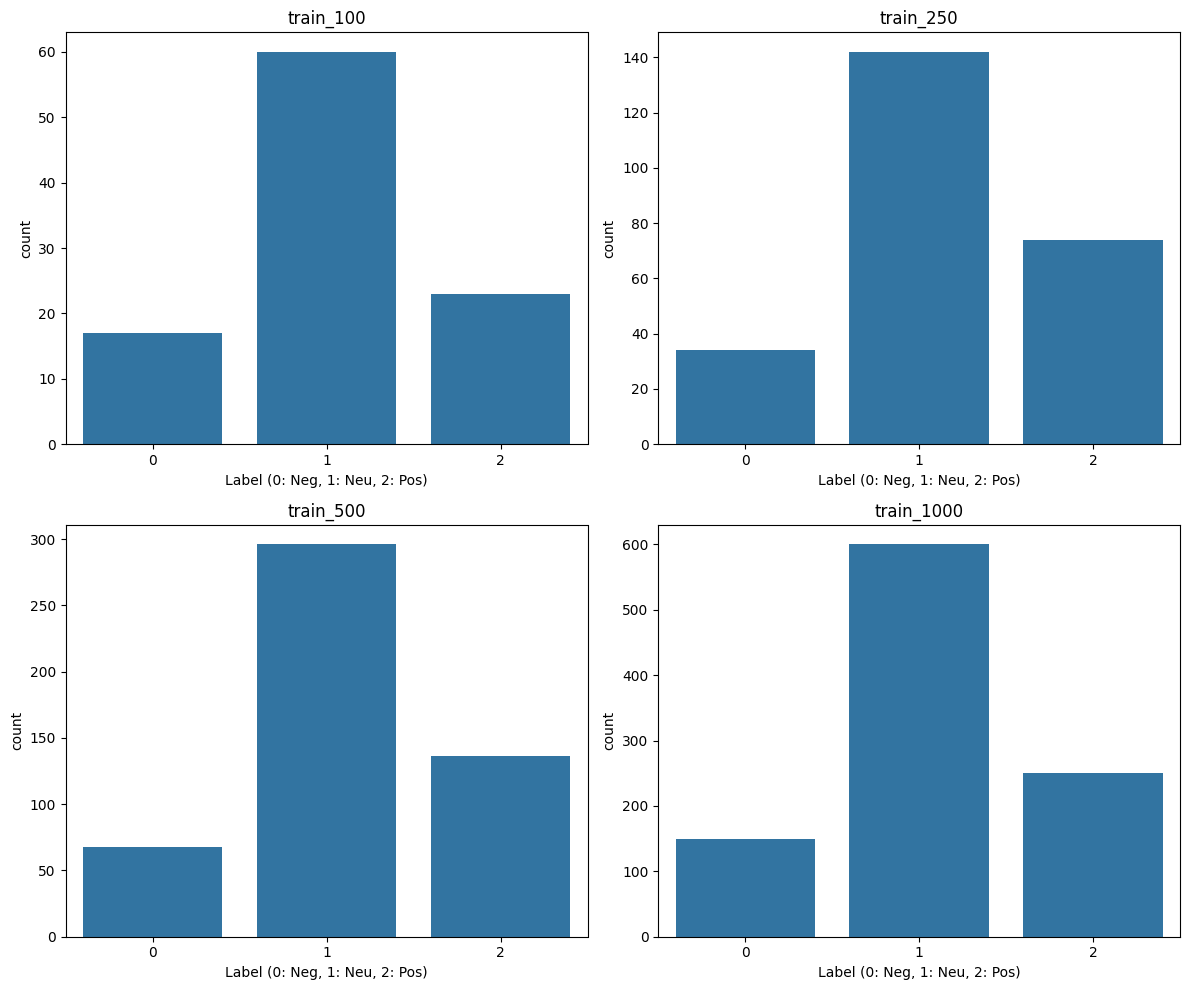

In [5]:
fig, axes = plt.subplots(2, 2, figsize=(12, 10))
axes = axes.flatten()

for i, size in enumerate(train_sizes):
    train_df = splits[f"train_{size}"]
    sns.countplot(x="label", data=train_df, ax=axes[i])
    axes[i].set_title(f"train_{size}")
    axes[i].set_xlabel("Label (0: Neg, 1: Neu, 2: Pos)")

plt.tight_layout()
plt.show()

## Split Refactor Summary

What changed in this step:
- Data loading is now agreement-aware and loads all four Financial PhraseBank agreement subsets.
- Hard-label training, validation, and the hidden pool now come only from deduplicated 100%-agreement data.
- `test_allagree` and `test_disagree` are frozen separately and can be reused across all later experiments.
- `hidden_allagree_pool` is fixed once and does not shrink as train size increases.

What still needs adaptation next:
- The existing downstream training cells still use `test_df = test_allagree_df` as a temporary compatibility alias.
- Weak-labeling and semi-supervised sections now target the fixed clean hidden pool, but they still need explicit dual-test-set reporting later.
- Embedding and LLM analysis cells still default to `test_df` and should later be extended to compare both test sets.

# Baseline Model Training

This notebook now runs a clean side-by-side baseline classifier comparison for:
- DistilBERT: `distilbert-base-uncased`
- ModernBERT: `answerdotai/ModernBERT-base`

The baseline logic stays in the notebook so the experiment flow remains visible and easy to adapt later.

In [6]:
class WeakLabeler:
    def __init__(self, model_name: str = "all-mpnet-base-v2"):
        self.model = SentenceTransformer(model_name)

    def encode(self, sentences: List[str]) -> np.ndarray:
        return self.model.encode(sentences, show_progress_bar=True)

    def train_knn(
        self, train_df: pd.DataFrame, n_neighbors: int = 5
    ) -> KNeighborsClassifier:
        embeddings = self.encode(train_df["sentence"].tolist())
        labels = train_df["label"].tolist()

        knn = KNeighborsClassifier(n_neighbors=n_neighbors)
        knn.fit(embeddings, labels)
        return knn

    def predict(
        self, knn: KNeighborsClassifier, unlabeled_df: pd.DataFrame
    ) -> pd.DataFrame:
        sentences = unlabeled_df["sentence"].tolist()
        embeddings = self.encode(sentences)

        weak_labels = knn.predict(embeddings)

        result_df = unlabeled_df.copy()
        result_df["label"] = weak_labels
        result_df["is_weak"] = True

        return result_df


## Build Baseline Learning Curves for Both Classifier Models

For this step, we extend the baseline comparison into a simple nested loop over both classifier backbones and all four hard-label training sizes.

Each run is evaluated on `val_allagree`, `test_allagree`, and `test_disagree` so we can compare scaling behavior on the clean and disagreement-aware test sets.

In [7]:
baseline_eval_splits = {
    "val_allagree": val_allagree_df,
    "test_allagree": test_allagree_df,
    "test_disagree": test_disagree_df,
}

baseline_results = []
baseline_train_sizes = train_sizes

for baseline_model_key, baseline_model_name in BASELINE_MODEL_NAMES.items():
    print(
        f"\n=== Baseline learning curve: {baseline_model_key} "
        f"({baseline_model_name}) ==="
    )

    for baseline_train_size in baseline_train_sizes:
        print(f"Training {baseline_model_key} on train_{baseline_train_size}")
        baseline_train_df = splits[f"train_{baseline_train_size}"]

        baseline_classifier = SentimentClassifier(
            model_name=baseline_model_name,
            num_labels=len(SENTIMENT_ID2LABEL),
        )
        baseline_classifier.set_label_mapping(SENTIMENT_ID2LABEL, SENTIMENT_LABEL2ID)

        train_dataset = prepare_text_dataset(
            baseline_train_df,
            baseline_classifier.tokenizer,
        )
        val_dataset = prepare_text_dataset(
            val_allagree_df,
            baseline_classifier.tokenizer,
        )
        data_collator = DataCollatorWithPadding(tokenizer=baseline_classifier.tokenizer)

        baseline_trainer = Trainer(
            model=baseline_classifier.model,
            args=create_training_args(
                output_dir=f"models/{baseline_model_key}_{baseline_train_size}",
                batch_size=16,
                epochs=3,
                seed=42,
            ),
            train_dataset=train_dataset,
            eval_dataset=val_dataset,
            data_collator=data_collator,
            compute_metrics=lambda eval_pred: compute_metrics(
                eval_pred,
                negative_label=NEGATIVE_LABEL,
            ),
        )

        baseline_trainer.train()

        for evaluation_split_name, evaluation_split_df in baseline_eval_splits.items():
            evaluation_dataset = prepare_text_dataset(
                evaluation_split_df,
                baseline_classifier.tokenizer,
            )
            evaluation_predictions = baseline_trainer.predict(evaluation_dataset)
            evaluation_metrics = compute_metrics(
                (evaluation_predictions.predictions, evaluation_predictions.label_ids),
                negative_label=NEGATIVE_LABEL,
            )

            baseline_results.append(
                {
                    "model_key": baseline_model_key,
                    "model_name": baseline_model_name,
                    "train_size": baseline_train_size,
                    "evaluation_split": evaluation_split_name,
                    **evaluation_metrics,
                }
            )

# TODO: Select one best classifier backbone for the later semi-supervised section.
# TODO: Start embedding comparison for weak labeling.
# TODO: Add direct agreement-impact discussion after the baseline curves.
print(f"Collected {len(baseline_results)} baseline evaluation rows.")


=== Baseline learning curve: distilbert (distilbert-base-uncased) ===
Training distilbert on train_100


Loading weights:   0%|          | 0/100 [00:00<?, ?it/s]

Map:   0%|          | 0/100 [00:00<?, ? examples/s]

Map:   0%|          | 0/181 [00:00<?, ? examples/s]

{'eval_loss': '0.9784', 'eval_accuracy': '0.6133', 'eval_macro_f1': '0.2534', 'eval_negative_precision': '0', 'eval_negative_recall': '0', 'eval_negative_f1': '0', 'eval_runtime': '0.689', 'eval_samples_per_second': '262.7', 'eval_steps_per_second': '17.42', 'epoch': '1'}


...

{'train_runtime': '44.01', 'train_samples_per_second': '68.17', 'train_steps_per_second': '4.295', 'train_loss': '0.2826', 'epoch': '3'}


Map:   0%|          | 0/181 [00:00<?, ? examples/s]

Map:   0%|          | 0/452 [00:00<?, ? examples/s]

Map:   0%|          | 0/516 [00:00<?, ? examples/s]

Collected 24 baseline evaluation rows.


## Baseline Learning Curve Results

In [8]:
baseline_results_df = pd.DataFrame(baseline_results)
baseline_results_df = baseline_results_df[
    [
        "model_key",
        "model_name",
        "train_size",
        "evaluation_split",
        "negative_f1",
        "accuracy",
        "macro_f1",
        "negative_precision",
        "negative_recall",
    ]
].sort_values(
    ["evaluation_split", "model_key", "train_size"],
    ascending=[True, True, True],
).reset_index(drop=True)

display(
    baseline_results_df.style.format(
        {
            "negative_f1": "{:.4f}",
            "accuracy": "{:.4f}",
            "macro_f1": "{:.4f}",
            "negative_precision": "{:.4f}",
            "negative_recall": "{:.4f}",
        }
    ).background_gradient(subset=["negative_f1"], cmap="YlGn")
)

,model_key,model_name,train_size,evaluation_split,negative_f1,accuracy,macro_f1,negative_precision,negative_recall
0,distilbert,distilbert-base-uncased,100,test_allagree,0.0000,0.6128,0.2533,0.0000,0.0000
1,distilbert,distilbert-base-uncased,250,test_allagree,0.0000,0.7035,0.4384,0.0000,0.0000
2,distilbert,distilbert-base-uncased,500,test_allagree,0.0000,0.7500,0.4995,0.0000,0.0000
3,distilbert,distilbert-base-uncased,1000,test_allagree,0.8852,0.9336,0.9106,0.8852,0.8852
4,modernbert,answerdotai/ModernBERT-base,100,test_allagree,0.0811,0.7500,0.5222,0.2308,0.0492
5,modernbert,answerdotai/ModernBERT-base,250,test_allagree,0.5424,0.7699,0.6766,0.5614,0.5246
6,modernbert,answerdotai/ModernBERT-base,500,test_allagree,0.4889,0.8164,0.7009,0.7586,0.3607
7,modernbert,answerdotai/ModernBERT-base,1000,test_allagree,0.9457,0.9624,0.9507,0.8971,1.0000
8,distilbert,distilbert-base-uncased,100,test_disagree,0.0000,0.5756,0.2435,0.0000,0.0000
9,distilbert,distilbert-base-uncased,250,test_disagree,0.0000,0.5775,0.2547,0.0000,0.0000


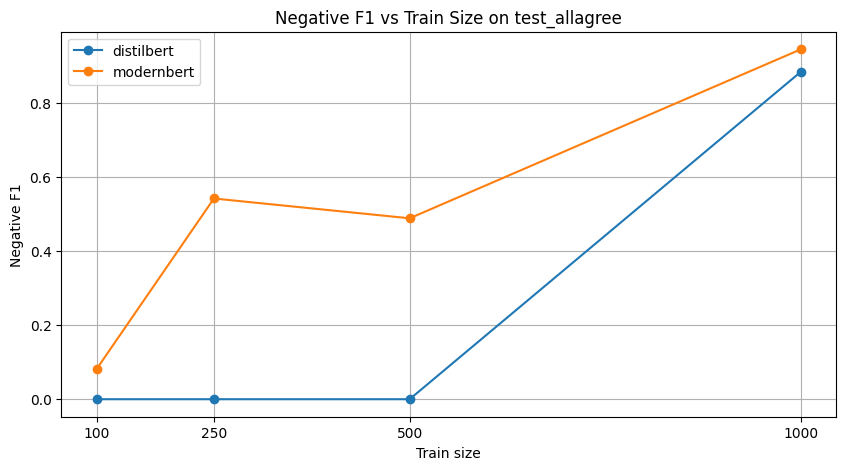

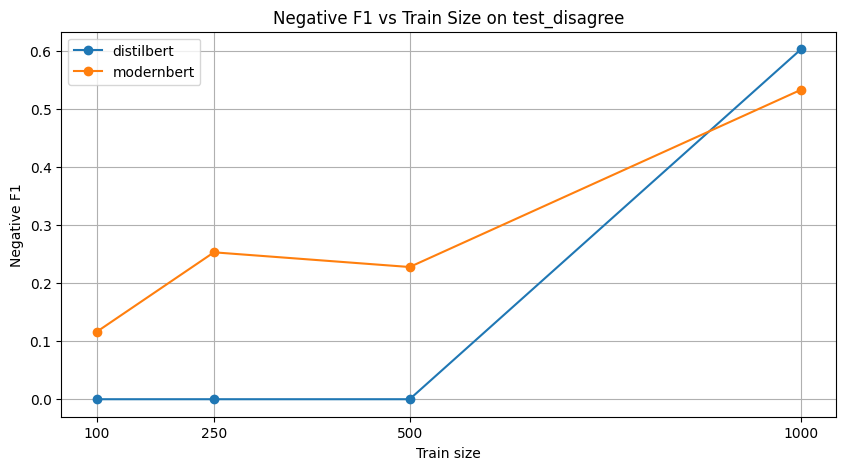

In [9]:
test_allagree_results_df = baseline_results_df[
    baseline_results_df["evaluation_split"] == "test_allagree"
]
test_disagree_results_df = baseline_results_df[
    baseline_results_df["evaluation_split"] == "test_disagree"
]

plt.figure(figsize=(10, 5))
for baseline_model_key in BASELINE_MODEL_NAMES:
    model_results_df = test_allagree_results_df[
        test_allagree_results_df["model_key"] == baseline_model_key
    ]
    plt.plot(
        model_results_df["train_size"],
        model_results_df["negative_f1"],
        marker="o",
        label=baseline_model_key,
    )

plt.title("Negative F1 vs Train Size on test_allagree")
plt.xlabel("Train size")
plt.ylabel("Negative F1")
plt.xticks(baseline_train_sizes)
plt.legend()
plt.grid(True)
plt.show()

plt.figure(figsize=(10, 5))
for baseline_model_key in BASELINE_MODEL_NAMES:
    model_results_df = test_disagree_results_df[
        test_disagree_results_df["model_key"] == baseline_model_key
    ]
    plt.plot(
        model_results_df["train_size"],
        model_results_df["negative_f1"],
        marker="o",
        label=baseline_model_key,
    )

plt.title("Negative F1 vs Train Size on test_disagree")
plt.xlabel("Train size")
plt.ylabel("Negative F1")
plt.xticks(baseline_train_sizes)
plt.legend()
plt.grid(True)
plt.show()

## Baseline Learning Curve Interpretation

TODO: Expand this short interpretation after running the learning-curve comparison.

- Check whether ModernBERT or DistilBERT scales better as train size increases.
- Check whether the gap between `test_allagree` and `test_disagree` stays large across train sizes.
- Decide which classifier backbone should be carried forward into the semi-supervised section.
- TODO: Add a direct agreement-impact discussion after choosing the stronger backbone.
- TODO: Add an optional `macro_f1` learning-curve plot later if it stays readable.

# Weak Labeling

This section only prepares embeddings for the later k-NN weak-labeling step. We compare one sentence-level SBERT model against one plain BERT baseline before generating any weak labels.


## Embedding Models and Scope

For this step:
- `sentence-transformers/all-MiniLM-L6-v2` is the SBERT-style sentence embedding model.
- `bert-base-uncased` is the plain BERT comparison baseline.
- SBERT uses the sentence embedding returned by the sentence-transformers model directly.
- Plain BERT uses simple mean pooling over token embeddings with the attention mask, not the CLS token.
- We keep the current clean `hard_label_train_pool` and `hidden_allagree_pool` setup.

TODO: In a later step, analyze annotator agreement level more explicitly inside the weak-labeling setup, not only on the held-out test splits.


In [ ]:
SBERT_MODEL_NAME = "sentence-transformers/all-MiniLM-L6-v2"
BERT_MODEL_NAME = "bert-base-uncased"
EMBEDDING_BATCH_SIZE = 32

print("SBERT model:", SBERT_MODEL_NAME)
print("Plain BERT model:", BERT_MODEL_NAME)
print("Embedding batch size:", EMBEDDING_BATCH_SIZE)


## Load Embedding Models

We keep the loading code explicit so the pooling choice is easy to inspect in the notebook.


In [ ]:
embedding_device = get_device()

sbert_model = SentenceTransformer(
    SBERT_MODEL_NAME,
    device=str(embedding_device),
)

bert_tokenizer = AutoTokenizer.from_pretrained(BERT_MODEL_NAME, use_fast=True)
bert_model = AutoModel.from_pretrained(BERT_MODEL_NAME)
bert_model.to(embedding_device)
bert_model.eval()


def encode_with_plain_bert(sentences, batch_size=EMBEDDING_BATCH_SIZE):
    """Plain BERT baseline: mean-pool token embeddings with the attention mask."""
    pooled_batches = []

    for start in range(0, len(sentences), batch_size):
        batch_sentences = sentences[start : start + batch_size]
        batch = bert_tokenizer(
            batch_sentences,
            padding=True,
            truncation=True,
            return_tensors="pt",
        )
        batch = {
            name: tensor.to(embedding_device)
            for name, tensor in batch.items()
        }

        with torch.no_grad():
            outputs = bert_model(**batch)

        token_embeddings = outputs.last_hidden_state
        attention_mask = batch["attention_mask"].unsqueeze(-1)
        summed_embeddings = (token_embeddings * attention_mask).sum(dim=1)
        token_counts = attention_mask.sum(dim=1).clamp(min=1)
        pooled_embeddings = summed_embeddings / token_counts
        pooled_batches.append(pooled_embeddings.cpu().numpy())

    return np.vstack(pooled_batches)


print("Embedding device:", embedding_device)


## Build Embeddings for the Seed Set and Hidden Pool

We embed the full `hard_label_train_pool` so the next step can slice the nested `train_100`, `train_250`, `train_500`, and `train_1000` seed sets directly from the same arrays.


In [ ]:
embedding_train_df = splits["hard_label_train_pool"].copy()
embedding_hidden_df = splits["hidden_allagree_pool"].copy()

embedding_train_texts = embedding_train_df["sentence"].tolist()
embedding_train_labels = embedding_train_df["label"].to_numpy()
embedding_hidden_texts = embedding_hidden_df["sentence"].tolist()
embedding_hidden_labels = embedding_hidden_df["label"].to_numpy()

embedding_counts_df = pd.DataFrame(
    [
        {
            "split": "hard_label_train_pool",
            "rows": len(embedding_train_df),
            "label_source": "observed hard labels",
        },
        {
            "split": "hidden_allagree_pool",
            "rows": len(embedding_hidden_df),
            "label_source": "hidden clean labels for later offline checks",
        },
    ]
)

display(embedding_counts_df)


In [ ]:
sbert_train_embeddings = sbert_model.encode(
    embedding_train_texts,
    batch_size=EMBEDDING_BATCH_SIZE,
    show_progress_bar=True,
)

sbert_hidden_embeddings = sbert_model.encode(
    embedding_hidden_texts,
    batch_size=EMBEDDING_BATCH_SIZE,
    show_progress_bar=True,
)

print("sbert_train_embeddings shape:", sbert_train_embeddings.shape)
print("sbert_hidden_embeddings shape:", sbert_hidden_embeddings.shape)


In [ ]:
bert_train_embeddings = encode_with_plain_bert(embedding_train_texts)
bert_hidden_embeddings = encode_with_plain_bert(embedding_hidden_texts)

print("bert_train_embeddings shape:", bert_train_embeddings.shape)
print("bert_hidden_embeddings shape:", bert_hidden_embeddings.shape)


In [ ]:
embedding_shapes_df = pd.DataFrame(
    [
        {
            "model": "SBERT",
            "model_name": SBERT_MODEL_NAME,
            "train_shape": tuple(sbert_train_embeddings.shape),
            "hidden_shape": tuple(sbert_hidden_embeddings.shape),
        },
        {
            "model": "BERT mean pool",
            "model_name": BERT_MODEL_NAME,
            "train_shape": tuple(bert_train_embeddings.shape),
            "hidden_shape": tuple(bert_hidden_embeddings.shape),
        },
    ]
)

display(embedding_shapes_df)

train_embedding_positions_by_size = {
    size: embedding_train_df.index.get_indexer(splits[f"train_{size}"].index)
    for size in train_sizes
}

sbert_train_embeddings_by_size = {
    size: sbert_train_embeddings[positions]
    for size, positions in train_embedding_positions_by_size.items()
}
bert_train_embeddings_by_size = {
    size: bert_train_embeddings[positions]
    for size, positions in train_embedding_positions_by_size.items()
}
train_texts_by_size = {
    size: splits[f"train_{size}"]["sentence"].tolist()
    for size in train_sizes
}
train_labels_by_size = {
    size: splits[f"train_{size}"]["label"].to_numpy()
    for size in train_sizes
}

embedding_artifacts = {
    "train_df": embedding_train_df,
    "hidden_df": embedding_hidden_df,
    "train_texts": embedding_train_texts,
    "train_labels": embedding_train_labels,
    "hidden_texts": embedding_hidden_texts,
    "hidden_labels": embedding_hidden_labels,
    "train_positions_by_size": train_embedding_positions_by_size,
    "train_texts_by_size": train_texts_by_size,
    "train_labels_by_size": train_labels_by_size,
    "sbert": {
        "model_name": SBERT_MODEL_NAME,
        "train_embeddings": sbert_train_embeddings,
        "hidden_embeddings": sbert_hidden_embeddings,
        "train_embeddings_by_size": sbert_train_embeddings_by_size,
    },
    "bert": {
        "model_name": BERT_MODEL_NAME,
        "train_embeddings": bert_train_embeddings,
        "hidden_embeddings": bert_hidden_embeddings,
        "train_embeddings_by_size": bert_train_embeddings_by_size,
    },
}


## Simple Embedding Diagnostics

Before building k-NN weak labels, we compare the two embedding spaces on the hard-labeled seed pool with simple cosine-based checks:
- mean intra-class cosine similarity
- mean inter-class cosine similarity
- leave-one-out 1-nearest-neighbor label purity
- class-centroid cosine similarity

If SBERT gives cleaner local neighborhoods and a larger same-label versus different-label gap, that is a good sign for the later k-NN weak-labeling step.


In [ ]:
embedding_sets = {
    "SBERT": sbert_train_embeddings,
    "BERT mean pool": bert_train_embeddings,
}

similarity_rows = []
nn_rows = []
centroid_similarity_tables = {}

for model_label, embeddings in embedding_sets.items():
    normalized_embeddings = embeddings / np.clip(
        np.linalg.norm(embeddings, axis=1, keepdims=True),
        a_min=1e-12,
        a_max=None,
    )

    cosine_matrix = normalized_embeddings @ normalized_embeddings.T
    same_label_mask = (
        embedding_train_labels[:, None] == embedding_train_labels[None, :]
    )
    diagonal_mask = np.eye(len(embedding_train_labels), dtype=bool)

    intra_class_values = cosine_matrix[same_label_mask & ~diagonal_mask]
    inter_class_values = cosine_matrix[~same_label_mask]

    similarity_rows.append(
        {
            "model": model_label,
            "mean_intra_class_cosine": intra_class_values.mean(),
            "mean_inter_class_cosine": inter_class_values.mean(),
            "similarity_gap": intra_class_values.mean() - inter_class_values.mean(),
        }
    )

    leave_one_out_matrix = cosine_matrix.copy()
    np.fill_diagonal(leave_one_out_matrix, -np.inf)
    nearest_neighbor_indices = leave_one_out_matrix.argmax(axis=1)
    nearest_neighbor_labels = embedding_train_labels[nearest_neighbor_indices]
    nn_rows.append(
        {
            "model": model_label,
            "leave_one_out_1nn_purity": (
                nearest_neighbor_labels == embedding_train_labels
            ).mean(),
        }
    )

    centroid_vectors = {}
    centroid_order = [SENTIMENT_ID2LABEL[label_id] for label_id in sorted(SENTIMENT_ID2LABEL)]
    for label_id, label_name in SENTIMENT_ID2LABEL.items():
        class_embeddings = normalized_embeddings[embedding_train_labels == label_id]
        centroid = class_embeddings.mean(axis=0)
        centroid = centroid / np.clip(np.linalg.norm(centroid), a_min=1e-12, a_max=None)
        centroid_vectors[label_name] = centroid

    centroid_table = pd.DataFrame(index=centroid_order, columns=centroid_order, dtype=float)
    for row_label in centroid_order:
        for col_label in centroid_order:
            centroid_table.loc[row_label, col_label] = float(
                centroid_vectors[row_label] @ centroid_vectors[col_label]
            )
    centroid_similarity_tables[model_label] = centroid_table.round(3)

embedding_similarity_df = pd.DataFrame(similarity_rows).round(3)
embedding_nn_purity_df = pd.DataFrame(nn_rows).round(3)
embedding_quality_df = embedding_similarity_df.merge(embedding_nn_purity_df, on="model")

display(embedding_quality_df)

for model_label, centroid_table in centroid_similarity_tables.items():
    print(f"\n{model_label} centroid cosine similarity")
    display(centroid_table)

fig, axes = plt.subplots(1, 2, figsize=(12, 4))

sns.barplot(
    data=embedding_quality_df,
    x="model",
    y="similarity_gap",
    ax=axes[0],
)
axes[0].set_title("Intra-class vs Inter-class Cosine Gap")
axes[0].set_ylabel("mean intra - mean inter")
axes[0].set_xlabel("")

sns.barplot(
    data=embedding_quality_df,
    x="model",
    y="leave_one_out_1nn_purity",
    ax=axes[1],
)
axes[1].set_title("Leave-One-Out 1-NN Label Purity")
axes[1].set_ylabel("purity")
axes[1].set_xlabel("")
axes[1].set_ylim(0, 1)

plt.tight_layout()
plt.show()


## k-NN Weak Label Generation

We now test direct weak-label generation on `hidden_allagree_pool` using one fixed clean seed set first: the largest available hard-label split.

For this step:
- compare SBERT vs plain BERT mean pooling
- compare `k = 3`, `k = 5`, and `k = 11`
- use simple majority vote over nearest neighbors
- break ties deterministically by taking the smallest label id returned by `argmax`

TODO: Later extend the same comparison across multiple train sizes and explicitly compare higher-agreement versus lower-agreement seed labels.


In [ ]:
WEAK_LABEL_K_VALUES = [3, 5, 11]
WEAK_LABEL_SEED_SIZE = max(train_sizes)

weak_label_seed_df = splits[f"train_{WEAK_LABEL_SEED_SIZE}"].copy()
weak_label_hidden_df = splits["hidden_allagree_pool"].copy()
weak_label_hidden_true_labels = weak_label_hidden_df["label"].to_numpy()

weak_label_embedding_sets = {
    "SBERT": {
        "seed_embeddings": sbert_train_embeddings_by_size[WEAK_LABEL_SEED_SIZE],
        "hidden_embeddings": sbert_hidden_embeddings,
    },
    "BERT mean pool": {
        "seed_embeddings": bert_train_embeddings_by_size[WEAK_LABEL_SEED_SIZE],
        "hidden_embeddings": bert_hidden_embeddings,
    },
}


def predict_knn_majority_vote(train_embeddings, train_labels, query_embeddings, k):
    """Use cosine neighbors and simple majority vote for transparent weak labels."""
    neighbor_search = NearestNeighbors(
        n_neighbors=k,
        metric="cosine",
        algorithm="brute",
    )
    neighbor_search.fit(train_embeddings)
    distances, neighbor_indices = neighbor_search.kneighbors(query_embeddings)
    neighbor_labels = train_labels[neighbor_indices]

    predicted_labels = []
    confidence_scores = []
    for row_labels in neighbor_labels:
        label_counts = np.bincount(
            row_labels,
            minlength=len(SENTIMENT_ID2LABEL),
        )
        predicted_label = label_counts.argmax()
        predicted_labels.append(predicted_label)
        confidence_scores.append(label_counts[predicted_label] / k)

    return (
        np.array(predicted_labels),
        neighbor_indices,
        distances,
        np.array(confidence_scores),
    )


weak_label_results = []
weak_label_predictions = {}
weak_label_confusion_matrices = {}

for embedding_name, embedding_values in weak_label_embedding_sets.items():
    seed_embeddings = embedding_values["seed_embeddings"]
    hidden_embeddings = embedding_values["hidden_embeddings"]
    seed_labels = train_labels_by_size[WEAK_LABEL_SEED_SIZE]

    for k in WEAK_LABEL_K_VALUES:
        predicted_labels, neighbor_indices, neighbor_distances, confidence_scores = (
            predict_knn_majority_vote(
                train_embeddings=seed_embeddings,
                train_labels=seed_labels,
                query_embeddings=hidden_embeddings,
                k=k,
            )
        )

        predicted_logits = np.eye(len(SENTIMENT_ID2LABEL))[predicted_labels]
        metrics = compute_metrics(
            (predicted_logits, weak_label_hidden_true_labels),
            negative_label=NEGATIVE_LABEL,
        )
        confusion = compute_confusion_matrix(
            true_labels=weak_label_hidden_true_labels,
            predicted_labels=predicted_labels,
            label_order=sorted(SENTIMENT_ID2LABEL),
        )

        setting_key = f"{embedding_name} | k={k}"
        weak_labeled_hidden_setting_df = weak_label_hidden_df.copy()
        weak_labeled_hidden_setting_df["true_label"] = weak_label_hidden_true_labels
        weak_labeled_hidden_setting_df["label"] = predicted_labels
        weak_labeled_hidden_setting_df["weak_label"] = predicted_labels
        weak_labeled_hidden_setting_df["weak_label_confidence"] = confidence_scores
        weak_labeled_hidden_setting_df["embedding_name"] = embedding_name
        weak_labeled_hidden_setting_df["k"] = k
        weak_labeled_hidden_setting_df["is_weak"] = True
        weak_labeled_hidden_setting_df["prediction_correct"] = (
            predicted_labels == weak_label_hidden_true_labels
        )

        weak_label_results.append(
            {
                "embedding_name": embedding_name,
                "k": k,
                "seed_size": WEAK_LABEL_SEED_SIZE,
                **metrics,
                "mean_vote_confidence": confidence_scores.mean(),
            }
        )
        weak_label_predictions[setting_key] = {
            "predicted_labels": predicted_labels,
            "neighbor_indices": neighbor_indices,
            "neighbor_distances": neighbor_distances,
            "confidence_scores": confidence_scores,
            "weak_labeled_hidden_df": weak_labeled_hidden_setting_df,
        }
        weak_label_confusion_matrices[setting_key] = confusion

print(f"Seed split used for weak labeling: train_{WEAK_LABEL_SEED_SIZE}")
print(f"Compared settings: {len(weak_label_results)}")


In [ ]:
weak_label_results_df = pd.DataFrame(weak_label_results)
weak_label_results_df = weak_label_results_df[
    [
        "embedding_name",
        "k",
        "seed_size",
        "accuracy",
        "macro_f1",
        "negative_precision",
        "negative_recall",
        "negative_f1",
        "mean_vote_confidence",
    ]
].sort_values(["embedding_name", "k"]).reset_index(drop=True)

metric_columns = [
    "accuracy",
    "macro_f1",
    "negative_precision",
    "negative_recall",
    "negative_f1",
    "mean_vote_confidence",
]

display(
    weak_label_results_df.style.format(
        {column: "{:.3f}" for column in metric_columns}
    ).highlight_max(
        subset=["negative_f1"],
        color="#d8f3dc",
    )
)


In [ ]:
ranking_columns = ["negative_f1", "macro_f1", "accuracy", "k"]
ranking_order = [False, False, False, True]

best_sbert_row = (
    weak_label_results_df[weak_label_results_df["embedding_name"] == "SBERT"]
    .sort_values(ranking_columns, ascending=ranking_order)
    .iloc[0]
)
best_bert_row = (
    weak_label_results_df[weak_label_results_df["embedding_name"] == "BERT mean pool"]
    .sort_values(ranking_columns, ascending=ranking_order)
    .iloc[0]
)
best_overall_row = (
    weak_label_results_df
    .sort_values(ranking_columns, ascending=ranking_order)
    .iloc[0]
)

best_embedding_name = best_overall_row["embedding_name"]
best_k = int(best_overall_row["k"])
best_setting_key = f"{best_embedding_name} | k={best_k}"
best_weak_labels = weak_label_predictions[best_setting_key]["predicted_labels"]
best_weak_label_results = best_overall_row.to_dict()
best_weak_labeled_hidden_df = weak_label_predictions[best_setting_key][
    "weak_labeled_hidden_df"
].copy()

weak_label_seed_for_next_step_df = weak_label_seed_df[["sentence", "label"]].copy()
weak_label_seed_for_next_step_df["true_label"] = weak_label_seed_for_next_step_df["label"]
weak_label_seed_for_next_step_df["weak_label"] = weak_label_seed_for_next_step_df["label"]
weak_label_seed_for_next_step_df["weak_label_confidence"] = 1.0
weak_label_seed_for_next_step_df["embedding_name"] = "hard_label_seed"
weak_label_seed_for_next_step_df["k"] = np.nan
weak_label_seed_for_next_step_df["is_weak"] = False
weak_label_seed_for_next_step_df["prediction_correct"] = True

best_combined_train_with_weak_labels_df = pd.concat(
    [
        weak_label_seed_for_next_step_df,
        best_weak_labeled_hidden_df[
            [
                "sentence",
                "label",
                "true_label",
                "weak_label",
                "weak_label_confidence",
                "embedding_name",
                "k",
                "is_weak",
                "prediction_correct",
            ]
        ],
    ],
    ignore_index=True,
)

best_settings_df = pd.DataFrame(
    [best_sbert_row.to_dict(), best_bert_row.to_dict(), best_overall_row.to_dict()]
)
best_settings_df.index = ["best_sbert", "best_bert", "best_overall"]
display(best_settings_df)

best_setting_rows = [best_sbert_row, best_bert_row]
fig, axes = plt.subplots(1, 2, figsize=(12, 5))

for ax, best_row in zip(axes, best_setting_rows):
    setting_key = f"{best_row['embedding_name']} | k={int(best_row['k'])}"
    confusion = weak_label_confusion_matrices[setting_key]
    label_order = confusion["label_order"]
    label_names = [SENTIMENT_ID2LABEL[label_id] for label_id in label_order]
    confusion_df = pd.DataFrame(
        confusion["matrix"],
        index=label_names,
        columns=label_names,
    )

    sns.heatmap(
        confusion_df,
        annot=True,
        fmt="d",
        cmap="Blues",
        cbar=False,
        ax=ax,
    )
    ax.set_title(f"{best_row['embedding_name']} weak labels, k={int(best_row['k'])}")
    ax.set_xlabel("Predicted weak label")
    ax.set_ylabel("True hidden label")

plt.tight_layout()
plt.show()

print("Best weak-label configuration:")
print(best_weak_label_results)
print(f"Combined seed + weak-label rows: {len(best_combined_train_with_weak_labels_df)}")


## Weak Labeling Interpretation

TODO after running this section:
- check whether SBERT clearly outperforms plain BERT for direct weak labeling
- identify which `k` works best on the hidden clean pool
- inspect whether the negative class remains the weakest class or becomes reliable enough
- decide whether the best weak labels look strong enough to justify semi-supervised retraining next
- later add an explicit comparison of high-agreement versus lower-agreement seed labels to address the agreement question more directly


## Weak Labeling Step Summary

What changed in this step:
- generated direct weak labels for `hidden_allagree_pool` with cosine k-NN over the largest clean hard-label seed split
- compared SBERT and plain BERT mean pooling across `k = 3`, `5`, and `11`
- evaluated each setting with accuracy, macro F1, negative-class metrics, and confusion matrices
- stored the best configuration in explicit notebook variables for the next step

Prepared variables for reuse:
- `best_embedding_name`
- `best_k`
- `best_weak_labels`
- `best_weak_label_results`
- `best_weak_labeled_hidden_df`
- `best_combined_train_with_weak_labels_df`

Next:
- use the best weak-label configuration for semi-supervised retraining
- then compare the retrained classifier against the baseline classifier results


# Semi-Supervised Training

This first semi-supervised step keeps the comparison narrow: one fixed clean seed split, one selected classifier backbone, and one direct comparison between hard-only training and hard-plus-weak training.


## Select the Classifier Backbone

We carry forward one classifier backbone into the semi-supervised experiment. The selection rule is simple: choose the backbone with the best `negative_f1` on `val_allagree` at the same largest clean train size used in the weak-labeling step.


In [ ]:
semisup_seed_size = WEAK_LABEL_SEED_SIZE

semisup_backbone_candidates_df = baseline_results_df[
    (baseline_results_df["evaluation_split"] == "val_allagree")
    & (baseline_results_df["train_size"] == semisup_seed_size)
].copy()

selected_backbone_row = (
    semisup_backbone_candidates_df
    .sort_values(["negative_f1", "macro_f1", "model_key"], ascending=[False, False, True])
    .iloc[0]
)
selected_backbone_key = selected_backbone_row["model_key"]
selected_backbone_name = selected_backbone_row["model_name"]

selected_backbone_df = pd.DataFrame([selected_backbone_row.to_dict()])
display(selected_backbone_df)

print("Selected backbone key:", selected_backbone_key)
print("Selected backbone model:", selected_backbone_name)


In [ ]:
semisup_baseline_train_df = splits[f"train_{semisup_seed_size}"][["sentence", "label"]].copy()
semisup_weak_train_df = best_combined_train_with_weak_labels_df[["sentence", "label"]].copy()

semisup_eval_splits = {
    "val_allagree": val_allagree_df,
    "test_allagree": test_allagree_df,
    "test_disagree": test_disagree_df,
}


def train_and_evaluate_semisup_run(run_name, train_df, output_dir):
    """Train one run and evaluate it on the fixed validation and test splits."""
    classifier = SentimentClassifier(
        model_name=selected_backbone_name,
        num_labels=len(SENTIMENT_ID2LABEL),
    )
    classifier.set_label_mapping(SENTIMENT_ID2LABEL, SENTIMENT_LABEL2ID)

    train_dataset = prepare_text_dataset(train_df, classifier.tokenizer)
    val_dataset = prepare_text_dataset(val_allagree_df, classifier.tokenizer)
    data_collator = DataCollatorWithPadding(tokenizer=classifier.tokenizer)

    trainer = Trainer(
        model=classifier.model,
        args=create_training_args(
            output_dir=output_dir,
            batch_size=16,
            epochs=3,
            seed=42,
        ),
        train_dataset=train_dataset,
        eval_dataset=val_dataset,
        data_collator=data_collator,
        compute_metrics=lambda eval_pred: compute_metrics(
            eval_pred,
            negative_label=NEGATIVE_LABEL,
        ),
    )
    trainer.train()

    run_results = []
    run_confusions = {}
    for evaluation_split_name, evaluation_split_df in semisup_eval_splits.items():
        evaluation_dataset = prepare_text_dataset(
            evaluation_split_df,
            classifier.tokenizer,
        )
        evaluation_predictions = trainer.predict(evaluation_dataset)
        evaluation_metrics = compute_metrics(
            (evaluation_predictions.predictions, evaluation_predictions.label_ids),
            negative_label=NEGATIVE_LABEL,
        )

        run_results.append(
            {
                "run_type": run_name,
                "backbone_key": selected_backbone_key,
                "backbone_name": selected_backbone_name,
                "train_size": len(train_df),
                "seed_size": semisup_seed_size,
                "evaluation_split": evaluation_split_name,
                **evaluation_metrics,
            }
        )

        if evaluation_split_name in {"test_allagree", "test_disagree"}:
            predicted_labels = np.argmax(evaluation_predictions.predictions, axis=-1)
            run_confusions[evaluation_split_name] = compute_confusion_matrix(
                true_labels=evaluation_predictions.label_ids,
                predicted_labels=predicted_labels,
                label_order=sorted(SENTIMENT_ID2LABEL),
            )

    return run_results, run_confusions


In [ ]:
semisup_baseline_results, semisup_baseline_confusions = train_and_evaluate_semisup_run(
    run_name="baseline_hard_only",
    train_df=semisup_baseline_train_df,
    output_dir=f"models/semisup_baseline_{selected_backbone_key}_{semisup_seed_size}",
)

semisup_weak_results, semisup_weak_confusions = train_and_evaluate_semisup_run(
    run_name="semi_supervised_hard_plus_weak",
    train_df=semisup_weak_train_df,
    output_dir=f"models/semisup_weak_{selected_backbone_key}_{semisup_seed_size}",
)


In [ ]:
semisup_results = semisup_baseline_results + semisup_weak_results

semisup_comparison_df = pd.DataFrame(semisup_results)
semisup_comparison_df = semisup_comparison_df[
    [
        "run_type",
        "backbone_key",
        "backbone_name",
        "train_size",
        "seed_size",
        "evaluation_split",
        "accuracy",
        "macro_f1",
        "negative_precision",
        "negative_recall",
        "negative_f1",
    ]
].sort_values(
    ["evaluation_split", "run_type"],
    ascending=[True, True],
).reset_index(drop=True)

semisup_metric_columns = [
    "accuracy",
    "macro_f1",
    "negative_precision",
    "negative_recall",
    "negative_f1",
]

display(
    semisup_comparison_df.style.format(
        {column: "{:.4f}" for column in semisup_metric_columns}
    ).background_gradient(
        subset=["negative_f1"],
        cmap="YlGn",
    )
)


In [ ]:
semisup_confusion_matrices = {
    "baseline_hard_only": semisup_baseline_confusions,
    "semi_supervised_hard_plus_weak": semisup_weak_confusions,
}

fig, axes = plt.subplots(2, 2, figsize=(12, 10))
plot_order = [
    ("baseline_hard_only", "test_allagree", axes[0, 0]),
    ("semi_supervised_hard_plus_weak", "test_allagree", axes[0, 1]),
    ("baseline_hard_only", "test_disagree", axes[1, 0]),
    ("semi_supervised_hard_plus_weak", "test_disagree", axes[1, 1]),
]

for run_type, split_name, ax in plot_order:
    confusion = semisup_confusion_matrices[run_type][split_name]
    label_order = confusion["label_order"]
    label_names = [SENTIMENT_ID2LABEL[label_id] for label_id in label_order]
    confusion_df = pd.DataFrame(
        confusion["matrix"],
        index=label_names,
        columns=label_names,
    )

    sns.heatmap(
        confusion_df,
        annot=True,
        fmt="d",
        cmap="Blues",
        cbar=False,
        ax=ax,
    )
    ax.set_title(f"{run_type} on {split_name}")
    ax.set_xlabel("Predicted label")
    ax.set_ylabel("True label")

plt.tight_layout()
plt.show()


## Semi-Supervised Interpretation

TODO after running this section:
- check whether weak labels improve `negative_f1` over the hard-only baseline
- compare whether gains are larger on `test_allagree` or `test_disagree`
- decide whether the semi-supervised setup looks promising enough to extend across all train sizes
- next, repeat the same comparison for `train_100`, `train_250`, `train_500`, and `train_1000` to build semi-supervised learning curves
- later add an explicit high-agreement versus lower-agreement seed-label comparison inside the weak-labeling process


## Semi-Supervised Step Summary

What changed in this step:
- selected one classifier backbone using the best `negative_f1` on `val_allagree` at the largest clean train size
- trained a fair hard-only baseline and a semi-supervised hard-plus-weak version of the same backbone
- evaluated both runs on `val_allagree`, `test_allagree`, and `test_disagree`
- added confusion matrices for both runs on both test sets

Prepared variables for the next step:
- `selected_backbone_name`
- `semisup_comparison_df`
- `semisup_baseline_results`
- `semisup_weak_results`
- `semisup_confusion_matrices`

Next:
- extend the same comparison across all train sizes to build semi-supervised learning curves
- later add the agreement-level weak-labeling comparison required by the assignment


# Bonus Analysis

This notebook covers the bonus tasks:
1.  **Embedding Visualization**: Using UMAP to visualize sentence embeddings.
2.  **LLM Few-Shot Classification**: Using GPT-4 (or similar) for sentiment analysis via prompting.

## 1. Embedding Visualization (UMAP)

Loading weights:   0%|          | 0/199 [00:00<?, ?it/s]

Batches:   0%|          | 0/15 [00:00<?, ?it/s]

/Users/stefanbinkert/Documents/FHNW_DS/NPR/NPR_MC_2/.venv/lib/python3.11/site-packages/umap/umap_.py:1952: UserWarning: n_jobs value 1 overridden to 1 by setting random_state. Use no seed for parallelism.
  warn(


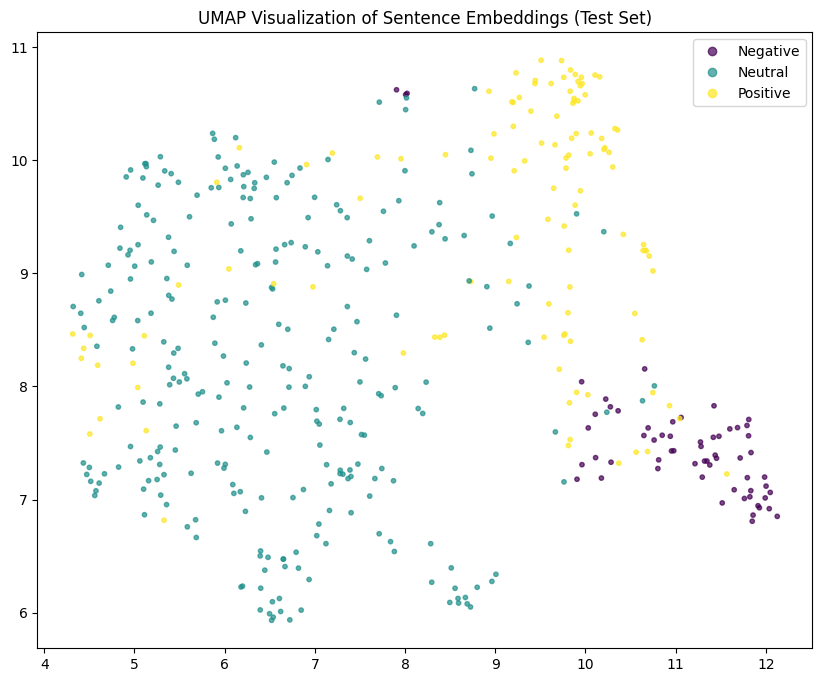

In [15]:
# Generate embeddings for test set
model = SentenceTransformer("all-mpnet-base-v2")
embeddings = model.encode(test_df["sentence"].tolist(), show_progress_bar=True)

# Reduce dimensionality with UMAP
reducer = umap.UMAP(n_neighbors=15, min_dist=0.1, random_state=42)
embedding_2d = reducer.fit_transform(embeddings)

# Plot
plt.figure(figsize=(10, 8))
scatter = plt.scatter(
    embedding_2d[:, 0],
    embedding_2d[:, 1],
    c=test_df["label"],
    cmap="viridis",
    s=10,
    alpha=0.7,
)
plt.legend(
    handles=scatter.legend_elements()[0], labels=["Negative", "Neutral", "Positive"]
)
plt.title("UMAP Visualization of Sentence Embeddings (Test Set)")
plt.show()

## 2. LLM Few-Shot Classification

**Note**: This requires an OpenAI API key. Please set `OPENAI_API_KEY` environment variable.

In [16]:
def normalize_llm_label(text):
    cleaned = text.strip().splitlines()[0].strip().strip(".:").lower()
    label_map = {"negative": 0, "neutral": 1, "positive": 2}
    return label_map.get(cleaned)


api_key = os.getenv("OPENAI_API_KEY")

if api_key:
    client = openai.OpenAI(api_key=api_key)
    
    def classify_with_llm(sentence):
        prompt = f"""
        You are a financial sentiment analysis assistant.
        Classify the sentiment of the following financial news sentence
        as Positive, Negative, or Neutral.
        Provide the label only.
        
        Examples:
        Sentence: "The company's profits surged by 50% this quarter."
        Sentiment: Positive
        
        Sentence: "The CEO resigned amidst a major scandal."
        Sentiment: Negative
        
        Sentence: "The company announced a new product line."
        Sentiment: Neutral
        
        Sentence: "{sentence}"
        Sentiment:
        """
        
        response = client.responses.create(
            model="gpt-5.1",
            reasoning={"effort": "none"},
            input=prompt
        )
        return response.output_text

    # Run on a small subset of test data
    subset_test = test_df.head(20).copy()
    subset_test['llm_pred'] = subset_test['sentence'].apply(classify_with_llm)
    
    subset_test['llm_pred_int'] = subset_test['llm_pred'].apply(normalize_llm_label)
    valid_predictions = subset_test.dropna(subset=['llm_pred_int']).copy()
    
    if valid_predictions.empty:
        print("No valid LLM labels were returned.")
    else:
        acc = accuracy_score(
            valid_predictions['label'],
            valid_predictions['llm_pred_int'],
        )
        print(
            f"LLM Few-Shot Accuracy (on {len(valid_predictions)} valid samples): "
            f"{acc:.4f}"
        )
    
else:
    print("OPENAI_API_KEY not found. Skipping LLM classification.")

LLM Few-Shot Accuracy (on 20 valid samples): 0.9500
